# Notebook for Visualization of Player-Conference Influence Deltas 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../ncaa_d1_player_deltas.csv')
df


,Unnamed: 0,index,conference,team,player,position,toi_(min),successful_oz_offensive_touches,failed_oz_offensive_touches,failed_oz_possessions,...,controlled_exit_with_play_after_rate,successful_defensive_dump-in_recoveries,failed_defensive_dump-in_recoveries,total_dump_out_attempts,dump_out_rate,successful_dump_out_attempts,total_icings,successful_oz_body_checks,successful_dz_body_checks,successful_body_checks
0,0,0,Independent,Stonehill College Skyhawks,Zach Aben,F,135:14,1.325179,1.546329,1.949394,...,-1.457838,1.736715,1.178641,-0.131162,-1.731198,-0.164045,1.770301,2.101965,1.340276,1.722580
1,1,1,Atlantic Hockey,College of the Holy Cross Crusaders,Michael Abgrall,F,534:41,0.727986,0.390310,0.267962,...,0.267067,-1.250064,-1.622353,-0.785673,-0.078183,-0.610080,-0.638005,0.268042,-0.843774,-0.664871
2,2,2,Big Ten,Ohio State University Buckeyes,Chris Able,D,601:37,-1.558633,-1.705093,-2.138877,...,-0.756475,2.040267,3.020268,2.716646,3.807273,2.867365,1.213134,-0.655342,-1.305897,-1.478943
3,3,3,CCHA,Michigan Tech University Huskies,Ryan Abraham,F,77:05,-0.997509,-1.024861,-1.347051,...,-1.116167,-1.877239,-2.304778,-2.407850,-1.438295,-2.485082,-1.219447,-1.706732,-2.035326,-2.401076
4,4,4,Independent,University of Alaska Anchorage Seawolves,Logan Acheson,D,616:58,1.938944,2.558493,2.803363,...,-0.393106,3.694705,2.940858,2.095940,-0.944100,1.963035,3.347329,1.205968,2.196348,2.195015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1543,1543,1543,NCHC,University of North Dakota Fighting Hawks,Bennett Zmolek,D,513:08,-2.194194,-1.719715,-1.675787,...,-0.569446,0.357819,0.273661,-1.271606,0.105487,-1.405361,-0.445948,0.223610,2.075029,2.088909
1544,1544,1544,Atlantic Hockey,Army Black Knights,Easton Zueger,D,509:06,-0.626929,-0.231749,-0.251846,...,-0.569508,0.369043,0.727270,1.392482,1.419485,1.406979,1.569833,-1.523953,1.039583,0.280000
1545,1545,1545,Hockey East,University of New Hampshire Wildcats,Conner de Haro,D,720:43,0.260333,-0.008740,0.032700,...,-0.901500,2.752881,2.692966,1.938664,0.606657,1.893655,2.282860,-1.025191,0.432274,-0.013461
1546,1546,1546,Atlantic Hockey,Robert Morris University Colonials,Luke van Why,D,593:08,0.189495,0.052922,-0.177588,...,0.905906,0.726752,0.246666,0.389062,0.649373,0.343439,0.465914,-1.523953,1.210798,0.752435


In [20]:
df['team'].value_counts()

team
University of Alaska Fairbanks Nanooks      28
Michigan Tech University Huskies            28
Canisius College Golden Griffins            28
University of Alaska Anchorage Seawolves    27
Bentley University Falcons                  27
                                            ..
Colgate University Raiders                  22
University of Connecticut Huskies           22
University of Minnesota Golden Gophers      22
Clarkson University Golden Knights          22
Penn State University Nittany Lions         22
Name: count, Length: 63, dtype: int64

In [2]:
df.set_index('conference', inplace=True)
df.columns = df.columns.str.replace('-', '_')


In [3]:
df = df.iloc[:, 2:]
df

,team,player,position,toi_(min),successful_oz_offensive_touches,failed_oz_offensive_touches,failed_oz_possessions,successful_dz_offensive_touches,failed_dz_offensive_touches,dz_offensive_touches_success_rate,...,controlled_exit_with_play_after_rate,successful_defensive_dump_in_recoveries,failed_defensive_dump_in_recoveries,total_dump_out_attempts,dump_out_rate,successful_dump_out_attempts,total_icings,successful_oz_body_checks,successful_dz_body_checks,successful_body_checks
conference,,,,,,,,,,,,,,,,,,,,,
Independent,Stonehill College Skyhawks,Zach Aben,F,135:14,1.325179,1.546329,1.949394,2.394185,1.948390,1.361384,...,-1.457838,1.736715,1.178641,-0.131162,-1.731198,-0.164045,1.770301,2.101965,1.340276,1.722580
Atlantic Hockey,College of the Holy Cross Crusaders,Michael Abgrall,F,534:41,0.727986,0.390310,0.267962,-1.030919,-1.841551,1.183852,...,0.267067,-1.250064,-1.622353,-0.785673,-0.078183,-0.610080,-0.638005,0.268042,-0.843774,-0.664871
Big Ten,Ohio State University Buckeyes,Chris Able,D,601:37,-1.558633,-1.705093,-2.138877,1.876218,2.197556,-0.209078,...,-0.756475,2.040267,3.020268,2.716646,3.807273,2.867365,1.213134,-0.655342,-1.305897,-1.478943
CCHA,Michigan Tech University Huskies,Ryan Abraham,F,77:05,-0.997509,-1.024861,-1.347051,-1.963637,-2.170602,-0.708795,...,-1.116167,-1.877239,-2.304778,-2.407850,-1.438295,-2.485082,-1.219447,-1.706732,-2.035326,-2.401076
Independent,University of Alaska Anchorage Seawolves,Logan Acheson,D,616:58,1.938944,2.558493,2.803363,5.072106,4.433355,1.951352,...,-0.393106,3.694705,2.940858,2.095940,-0.944100,1.963035,3.347329,1.205968,2.196348,2.195015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NCHC,University of North Dakota Fighting Hawks,Bennett Zmolek,D,513:08,-2.194194,-1.719715,-1.675787,0.307819,-0.260287,0.983840,...,-0.569446,0.357819,0.273661,-1.271606,0.105487,-1.405361,-0.445948,0.223610,2.075029,2.088909
Atlantic Hockey,Army Black Knights,Easton Zueger,D,509:06,-0.626929,-0.231749,-0.251846,-0.330704,0.281023,-1.177324,...,-0.569508,0.369043,0.727270,1.392482,1.419485,1.406979,1.569833,-1.523953,1.039583,0.280000
Hockey East,University of New Hampshire Wildcats,Conner de Haro,D,720:43,0.260333,-0.008740,0.032700,1.688992,2.618802,-0.930290,...,-0.901500,2.752881,2.692966,1.938664,0.606657,1.893655,2.282860,-1.025191,0.432274,-0.013461


In [4]:
df.columns

Index(['team', 'player', 'position', 'toi_(min)',
       'successful_oz_offensive_touches', 'failed_oz_offensive_touches',
       'failed_oz_possessions', 'successful_dz_offensive_touches',
       'failed_dz_offensive_touches', 'dz_offensive_touches_success_rate',
       ...
       'controlled_exit_with_play_after_rate',
       'successful_defensive_dump_in_recoveries',
       'failed_defensive_dump_in_recoveries', 'total_dump_out_attempts',
       'dump_out_rate', 'successful_dump_out_attempts', 'total_icings',
       'successful_oz_body_checks', 'successful_dz_body_checks',
       'successful_body_checks'],
      dtype='object', length=172)

# First Scatterplot of Player Deltas

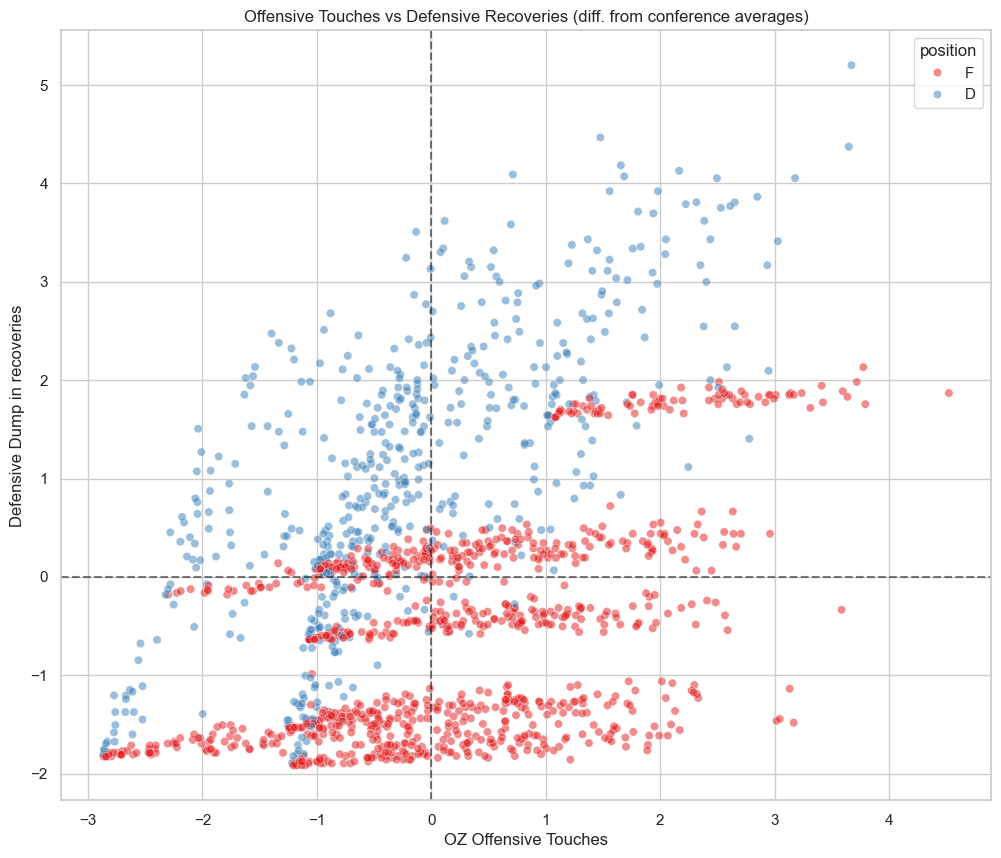

In [5]:
df.reset_index('conference', inplace=True)


sns.set_theme(style='whitegrid')

plt.figure(figsize=(12,10))
sns.scatterplot(
    data=df,
    x='successful_oz_offensive_touches',
    y='successful_defensive_dump_in_recoveries',
    hue='position',
    alpha=0.5,
    palette='Set1'
)

plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

plt.title('Offensive Touches vs Defensive Recoveries (diff. from conference averages)')
plt.xlabel('OZ Offensive Touches')
plt.ylabel('Defensive Dump in recoveries')
plt.show()

**make this graph interactive to be able to extract any information at all**

In [ ]:
import plotly.express as px

fig = px.scatter(
    df,
    x='successful_oz_offensive_touches',
    y='successful_defensive_dump_in_recoveries',
    color='position',
    hover_name='player',
    hover_data=['team', 'conference'],
    color_discrete_sequence=['#ef553b', '#636efa'],
    opacity=0.6,
    title='Offensive Touches vs Defensive Recoveries (Diff. from Conference Avg.)'
)
fig.add_hline(y=0, line_dash="dash", line_color="black", opacity=0.5)
fig.add_vline(x=0, line_dash="dash", line_color="black", opacity=0.5)

fig.update_layout(
    xaxis_title='OZ Offensive Touches',
    yaxis_title='Defensive Dump-in Recoveries',
    template='plotly_white',
    width=900,
    height=700
)

fig.show()

In [8]:
fig = px.scatter(
    df,
    x='successful_oz_offensive_touches',
    y='successful_defensive_dump_in_recoveries',
    color='conference',
    hover_name='player',
    hover_data=['team', 'position'],
    color_discrete_sequence=px.colors.qualitative.Plotly,
    opacity=0.6,
    title='Offensive Touches vs Defensive Recoveries (Diff. from Conference Avg.)'
)
fig.add_hline(y=0, line_dash="dash", line_color="black", opacity=0.5)
fig.add_vline(x=0, line_dash="dash", line_color="black", opacity=0.5)

fig.update_layout(
    xaxis_title='OZ Offensive Touches',
    yaxis_title='Defensive Dump-in Recoveries',
    template='plotly_white',
    width=900,
    height=700
)

fig.show()

In [11]:
conference_audit = df.groupby('conference')[[
    'successful_oz_offensive_touches',
    'successful_defensive_dump_in_recoveries'
]].mean().round(4)

conference_audit

,successful_oz_offensive_touches,successful_defensive_dump_in_recoveries
conference,,
Atlantic Hockey,0.0172,-0.7591
Big Ten,-0.7752,0.6218
CCHA,0.0841,-1.1348
ECAC,0.3020,0.8184
Hockey East,0.2667,0.1478
Independent,2.0941,2.2555
NCHC,-1.3570,-1.0192


In [12]:
stats_to_fix = df.select_dtypes('number').columns
df[stats_to_fix] = df.groupby('conference')[stats_to_fix].transform(lambda x: x - x.mean())
conference_audit = df.groupby('conference')[[
    'successful_oz_offensive_touches', 
    'successful_defensive_dump_in_recoveries'
]].mean().round(4)

conference_audit

,successful_oz_offensive_touches,successful_defensive_dump_in_recoveries
conference,,
Atlantic Hockey,0.0,-0.0
Big Ten,-0.0,0.0
CCHA,-0.0,0.0
ECAC,0.0,-0.0
Hockey East,0.0,0.0
Independent,0.0,-0.0
NCHC,0.0,0.0


In [13]:
import plotly.express as px

fig = px.scatter(
    df,
    x='successful_oz_offensive_touches',
    y='successful_defensive_dump_in_recoveries',
    color='conference',
    hover_name='player',
    hover_data=['team', 'position'],
    color_discrete_sequence=px.colors.qualitative.Plotly,
    opacity=0.6,
    title='Offensive Touches vs Defensive Recoveries (TRUE Relative Dominance)'
)

# Reference lines at 0 (now perfectly centered for everyone)
fig.add_hline(y=0, line_dash="dash", line_color="black", opacity=0.5)
fig.add_vline(x=0, line_dash="dash", line_color="black", opacity=0.5)

fig.update_layout(
    xaxis_title='OZ Offensive Touches (Delta)',
    yaxis_title='Defensive Dump-in Recoveries (Delta)',
    template='plotly_white',
    width=900,
    height=700
)

fig.show()

In [21]:
uconn_df = df[df['team'].str.contains('University of Connecticut', case=False, na=False)].reset_index(drop=True)
fig = px.scatter(
    uconn_df,
    x='successful_oz_offensive_touches',
    y='successful_defensive_dump_in_recoveries',
    color='position',
    hover_name='player',
    hover_data=['toi_(min)'],
    color_discrete_sequence=['#ef553b', '#636efa'],
    opacity=0.8,
    title='UConn Skaters: Production Relative to Hockey East Baseline'    
)
fig.add_hline(y=0, line_dash="dash", line_color="black", opacity=0.5)
fig.add_vline(x=0, line_dash="dash", line_color="black", opacity=0.5)
fig.update_layout(
    xaxis_title='OZ Offensive Touches',
    yaxis_title='Defensive Dump-in Recoveries',
    template='plotly_white',
    width=900,
    height=700
)

fig.show()

